# Equation of state via `eos_volume_scan`

Scans the cell volume of a Cu fcc bulk, evaluates each strained
structure with the ASE EMT calculator, and fits the Birch-Murnaghan
equation of state to extract the equilibrium volume, energy and
bulk modulus.


In [1]:
from ase.calculators.emt import EMT

from pyiron_workflow_atomistics.engine import ASEEngine, CalcInputMinimize
from pyiron_workflow_atomistics.structure import get_bulk
from pyiron_workflow_atomistics.physics.bulk import eos_volume_scan

engine = ASEEngine(
    EngineInput=CalcInputMinimize(force_convergence_tolerance=0.05),
    calculator=EMT(),
    working_directory="./_eos_runs",
)


In [2]:
structure = get_bulk.node_function("Cu", crystalstructure="fcc", a=3.6, cubic=True)

wf = eos_volume_scan(
    base_structure=structure,
    engine=engine,
    axes=["a", "b", "c"],
    strain_range=(-0.05, 0.05),
    num_points=7,
)
wf.run()

print(f"v0 = {wf.outputs.v0.value:.3f} A^3")
print(f"e0 = {wf.outputs.e0.value:.4f} eV")
print(f"B  = {wf.outputs.B.value:.1f} GPa")


      Step     Time          Energy          fmax
BFGS:    0 14:52:15        0.422697        0.000000


      Step     Time          Energy          fmax
BFGS:    0 14:52:15        0.152007        0.000000


      Step     Time          Energy          fmax
BFGS:    0 14:52:15        0.007050        0.000000


      Step     Time          Energy          fmax
BFGS:    0 14:52:15       -0.026755        0.000000


      Step     Time          Energy          fmax
BFGS:    0 14:52:15        0.034582        0.000000


      Step     Time          Energy          fmax
BFGS:    0 14:52:15        0.176812        0.000000


      Step     Time          Energy          fmax
BFGS:    0 14:52:15        0.388384        0.000000


v0 = 46.271 A^3
e0 = -0.0278 eV
B  = 133.5 GPa


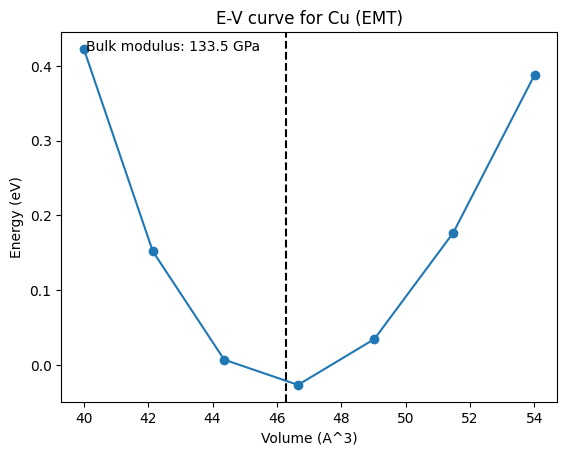

In [3]:
from matplotlib import pyplot as plt

volumes = wf.outputs.volumes.value
energies = wf.outputs.energies.value
v0 = wf.outputs.v0.value
B = wf.outputs.B.value

plt.plot(volumes, energies, marker="o")
plt.axvline(v0, color="k", linestyle="--")
plt.xlabel("Volume (A^3)")
plt.ylabel("Energy (eV)")
plt.title("E-V curve for Cu (EMT)")
plt.text(0.05, 0.95, f"Bulk modulus: {B:.1f} GPa", transform=plt.gca().transAxes)
plt.show()
